In [1]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 
import rcFun

In [2]:
Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')

In [3]:
qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 6
# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)

In [9]:
rateList = np.logspace(-4,-1,4)
N=2000
purities_wo_msm = np.zeros([len(rateList),N])
negativities_wo_msm = np.zeros([len(rateList),N])
Nqubit=6

for [ind,r] in enumerate(rateList):
    startTime = time.time()
    rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

    for s in range(round(0.2/r)): 
        purities_wo_msm[ind,s]=rcFun.calcPurity(rho.toarray())
        negativities_wo_msm[ind,s]=rcFun.calcNegativity(rho.toarray(),[n for n in range(Nqubit//2)])

        # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
        allKrausOps = rcFun.mkGlobalKrausOps(layer=s, Nqubit=Nqubit, rate=r, dt=5, ldbldOp=rcFun.S_Z, debug=False)
        # ok the trace is not 1

        # Then the based on which layer, the evolve Kraus pick one of the 2 sets
        rho = rcFun.evolveKrausU(allKrausOps, rho, debug = False)
        
    print(time.time()-startTime)


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  if sys.path[0] == '':
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  del sys.path[0]


1040.5900709629059
138.26336097717285
13.38426399230957
1.2303459644317627


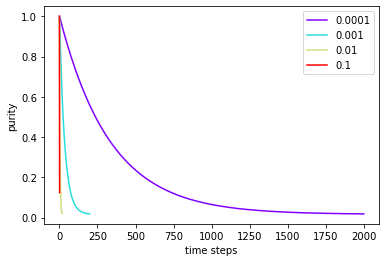

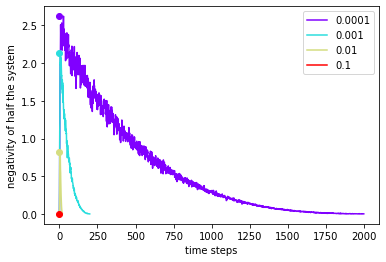

In [30]:
# no projective measurement
# Rescale to the steady state behavior

plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    plt.plot([t for t in range(round(0.2/r))], purities_wo_msm[ind,:round(0.2/r)],c=c)
    
plt.xlabel('time steps')
plt.ylabel('purity')
plt.legend(rateList)

plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    plt.plot(negativities_wo_msm[ind,:round(0.2/r)],c=c)
plt.legend(rateList)
plt.xlabel('time steps')
plt.ylabel('negativity of half the system')
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    plt.plot(max(negativities_wo_msm[ind,:round(0.2/r)]),'o',c=c)


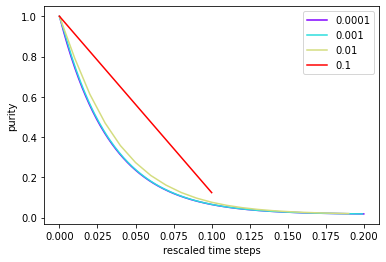

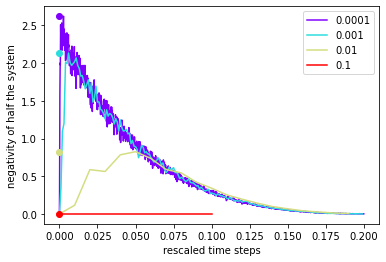

In [42]:
plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    plt.plot(np.array([t for t in range(round(0.2/r))])*r, purities_wo_msm[ind,:round(0.2/r)],c=c)
    
plt.xlabel('rescaled time steps')
plt.ylabel('purity')
plt.legend(rateList)

plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    plt.plot(np.array([t for t in range(round(0.2/r))])*r,negativities_wo_msm[ind,:round(0.2/r)],c=c)
plt.legend(rateList)
plt.xlabel('rescaled time steps')
plt.ylabel('negativity of half the system')
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    plt.plot(max(negativities_wo_msm[ind,:round(0.2/r)]),'o',c=c)


    

There is no point using dephasing/relaxation rate >=0.1. Figure out why.

In [51]:
# Introduce small measurement probabilities
rateList = [0,1e-4,1e-3,1e-2] #np.logspace(-3,1,5)
purities_005 = np.zeros([len(rateList),2000])
negativities_005 = np.zeros([len(rateList),2000])
Nqubit=6
probMsm=0.05
Nens=25

for [ind,r] in enumerate(rateList):
    startTime = time.time()
    
    if r<1e-5:
        totalSteps = 2000
    else:
        totalSteps = round(0.2/r)
        
    for n in range(Nens):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

        for s in range(totalSteps): 
            purities_005[ind,s]+=rcFun.calcPurity(rho.toarray())/Nens
            negativities_005[ind,s]+=rcFun.calcNegativity(rho.toarray(),[n for n in range(Nqubit//2)])/Nens

            # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
            allKrausOps = rcFun.mkGlobalKrausOps(layer=s, Nqubit=Nqubit, rate=r, dt=5, ldbldOp=rcFun.S_Z, debug=False)

            # Then the based on which layer, the evolve Kraus pick one of the 2 sets
            rho = rcFun.evolveKrausU(allKrausOps, rho, debug = False)

            rho = rcFun.mkS_zMsm(probMsm, rho)

    print(time.time()-startTime)



/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:22: ComplexWarning: Casting complex values to real discards the imaginary part


2801.947143316269
17484.760058164597
2425.8521859645844
281.0793640613556


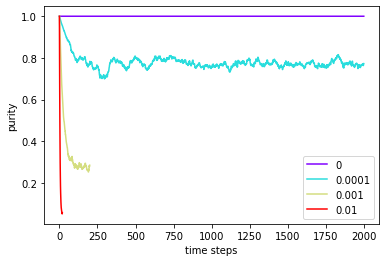

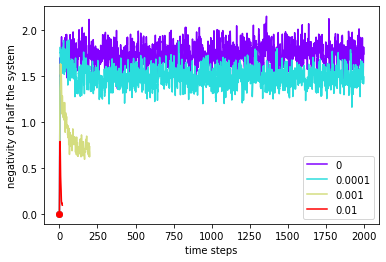

In [68]:
# no projective measurement

plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    if r==0:
        tmax=2000
    else:
        tmax=round(0.2/r)
    plt.plot([t for t in range(tmax)], purities_005[ind,:tmax],c=c)
    
plt.xlabel('time steps')
plt.ylabel('purity')
plt.legend(rateList)

plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    if r==0:
        tmax=2000
    else:
        tmax=round(0.2/r)
    plt.plot(negativities_005[ind,:tmax],c=c)
plt.legend(rateList)
plt.xlabel('time steps')
plt.ylabel('negativity of half the system')
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    if r==0:
        tmax=2000
    else:
        tmax=round(0.2/r)
    plt.plot(min(negativities_005[ind,:tmax]),'o',c=c)


Text(0, 0.5, 'rescaled negativity of half the system')

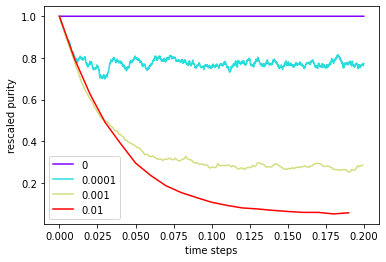

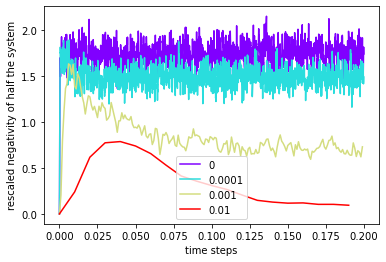

In [69]:
# Rescale to the steady state behavior
plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    if r==0:
        tmax=2000
        plt.plot(np.array([t for t in range(tmax)])*1e-4, purities_005[ind,:tmax],c=c)

    else:
        tmax=round(0.2/r)
        plt.plot(np.array([t for t in range(tmax)])*r, purities_005[ind,:tmax],c=c)

plt.xlabel('time steps')
plt.ylabel('rescaled purity')
plt.legend(rateList)

plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    if r==0:
        tmax=2000
        plt.plot(np.array([t for t in range(tmax)])*1e-4, negativities_005[ind,:tmax],c=c)

    else:
        tmax=round(0.2/r)
        plt.plot(np.array([t for t in range(tmax)])*r, negativities_005[ind,:tmax],c=c)
plt.legend(rateList)
plt.xlabel('time steps')
plt.ylabel('rescaled negativity of half the system')


Seems to work i.e. posisbly in the volume law phase. Maybe the probability measurement (0.05) needs to be ~ $10 \times \Gamma dt=0.005$ for the system to have interesting entanglement.

In [10]:
# Introduce probability of measurement close to p_c = 0.16

rateList = np.array([0,1e-4,1e-3,1e-2]) #np.logspace(-3,1,5)
purities_016 = np.zeros([len(rateList),400])
negativities_016 = np.zeros([len(rateList),400])
mutualInfo_016 = np.zeros([len(rateList),400])
Nqubit=6
probMsm=0.16
Nens=50


for [ind,r] in enumerate(rateList):
    startTime = time.time()
    
    for n in range(Nens):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

        for s in range(400):
            purities_016[ind,s]+=rcFun.calcPurity(rho.toarray())/Nens
            negativities_016[ind,s]+=rcFun.calcNegativity(rho.toarray(),[n for n in range(Nqubit//2)])/Nens

            # mutual info 
            S1 = rcFun.calcS(rho.toarray(), partiesToTraceOut = list(range(0, Nqubit//2-1)))
            S2 = rcFun.calcS(rho.toarray(), partiesToTraceOut = list(range(Nqubit//2, Nqubit)))
            S = rcFun.calcS(rho.toarray(), partiesToTraceOut = [])
            mutualInfo_016[ind,s] += (S1+S2-S)/Nens

            # OK this the KrausOps can be computed outside of the loop, which gives one 2 sets of Kraus ops
            allKrausOps = rcFun.mkGlobalKrausOps(layer=s, Nqubit=Nqubit, rate=r, dt=5, ldbldOp=rcFun.S_Z, debug=False)
            # ok the trace is not 1

            # Then the based on which layer, the evolve Kraus pick one of the 2 sets
            rho = rcFun.evolveKrausU(allKrausOps, rho, debug = False)

            rho = rcFun.mkS_zMsm(probMsm, rho)
            
    print(time.time() - startTime)


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:20: ComplexWarning: Casting complex values to real discards the imaginary part


930.4293720722198
6107.789948940277
6016.93026304245
5995.062439918518


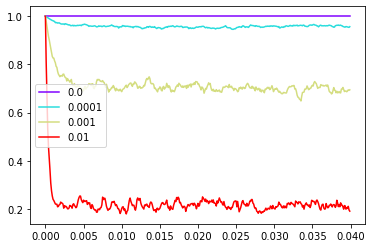

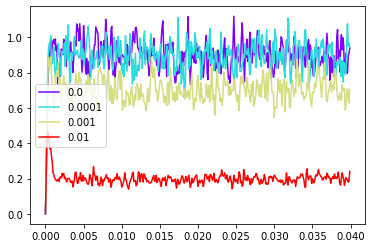

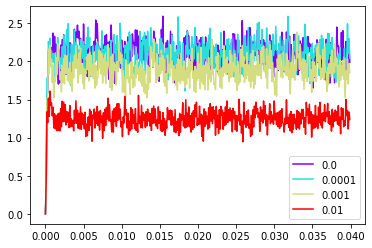

In [11]:
plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    tmax = 400
    plt.plot(np.array([t for t in range(tmax)])*1e-4, purities_016[ind,:tmax],c=c)
    
plt.legend(rateList)

        
plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    tmax = 400
    plt.plot(np.array([t for t in range(tmax)])*1e-4, negativities_016[ind,:tmax],c=c)
plt.legend(rateList)

        
plt.figure()
color = iter(plt.cm.rainbow(np.linspace(0,1,4)))
for [ind,r] in enumerate(rateList):
    c = next(color)
    tmax = 400
    plt.plot(np.array([t for t in range(tmax)])*1e-4, mutualInfo_016[ind,:tmax],c=c)
plt.legend(rateList)



In [65]:
1/280

0.0035714285714285713

OK it works.

Without projective measurement, when the dephasing rate is from order 1e-3 to 1e3, the negativities show two qualitative behaviors when the rate is above 1 and below 1 - when gamma<1, the entanglement is allowed to grow very fast initally but eventually decays to 0, while when gamma>1, the state jumps to the two allowed states dictated by the Lindblad operator. One can only imagine that introducing projective measurement would enlarge the fluctuation but would not change the value of negativities in the steady state.

Now WITH small measurement rate 0.05, 0.1 and 0.2, and when the dephasing rate is small, the negativities do not behave drastically different from that without dephasing. Perhaps this signifies that there could be EPT for open quantum systems but the dephasing rate needs to be very small.